# 1. Configuration et imports

In [11]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Ajout du dossier racine au PATH pour importer src
sys.path.append(str(Path("..").resolve()))
 
from src.data.loader import compute_train_rul, load_cmapss_subset


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Chargement des données brutes

In [12]:
DATA_RAW = Path("../data/raw")

df_train, df_test, df_rul = load_cmapss_subset(DATA_RAW, subset="FD004")
df_train = compute_train_rul(df_train)

print(
    f"Dimensions Train  : {df_train.shape} (lignes, colonnes avec la colonne 'rul')"
)
print(f"Dimensions Test  : {df_test.shape}")
print(f"Dimensions RUL  : {df_rul.shape}")


Dimensions Train  : (61249, 27) (lignes, colonnes avec la colonne 'rul')
Dimensions Test  : (41214, 26)
Dimensions RUL  : (248, 1)


# 3. Audit des données

In [13]:
# 1. Valeurs manquantes
missing_train = df_train.isna().sum().sum()
missing_test = df_test.isna().sum().sum()
missing_rul = df_rul.isna().sum().sum()

print(f"NaNs dans Train : {missing_train}")
print(f"NaNs dans Test : {missing_test}")
print(f"NaNs dans RUL : {missing_rul}")


# 2. Nombre de moteurs uniques 
n_train = df_train["unit_id"].nunique()
n_test = df_test["unit_id"].nunique()
print(f"\nMoteurs uniques dans Train : {n_train} (attendu : 249)")
print(f"\nMoteurs uniques dans Test : {n_test} (attendu : 248)")


NaNs dans Train : 0
NaNs dans Test : 0
NaNs dans RUL : 0

Moteurs uniques dans Train : 249 (attendu : 249)

Moteurs uniques dans Test : 248 (attendu : 248)


# 4. Analyse de la durée de vie des moteurs (Train)

Statistiques descriptives de la durée de vie des moteurs :


count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: time_cycles, dtype: float64

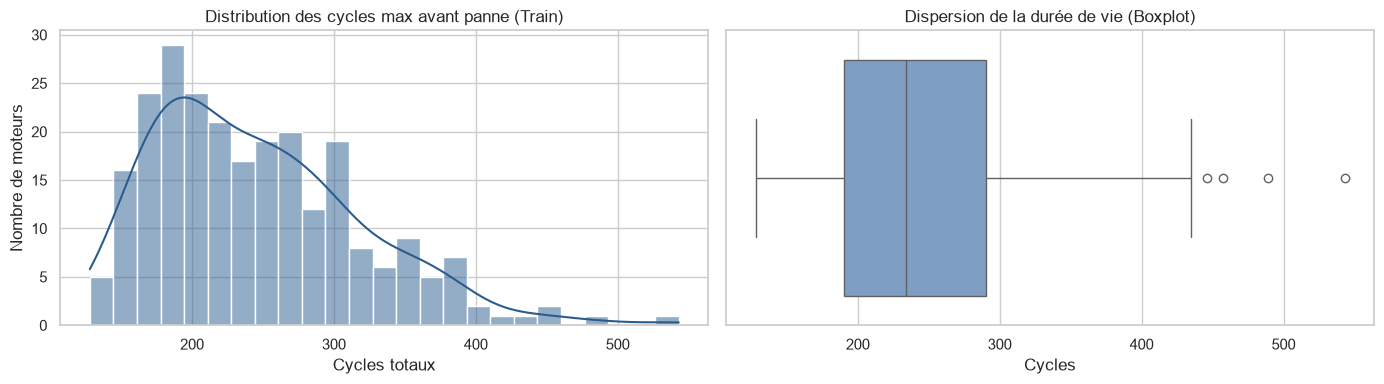

In [14]:
lifespans = df_train.groupby("unit_id")["time_cycles"].max()

print("Statistiques descriptives de la durée de vie des moteurs :")
display(lifespans.describe())

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,4))

sns.histplot(lifespans, kde=True, bins=25, ax= ax1, color="#2b5c8f")
ax1.set_title("Distribution des cycles max avant panne (Train)")
ax1.set_xlabel("Cycles totaux")
ax1.set_ylabel("Nombre de moteurs")

sns.boxplot(x=lifespans, ax=ax2, color="#729fcf")
ax2.set_title("Dispersion de la durée de vie (Boxplot)")
ax2.set_xlabel("Cycles")

plt.tight_layout()
plt.savefig(
    "../reports/figures/01_engines_lifespan_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



# 5. Etude de variabilité des capteurs
FD004 a 

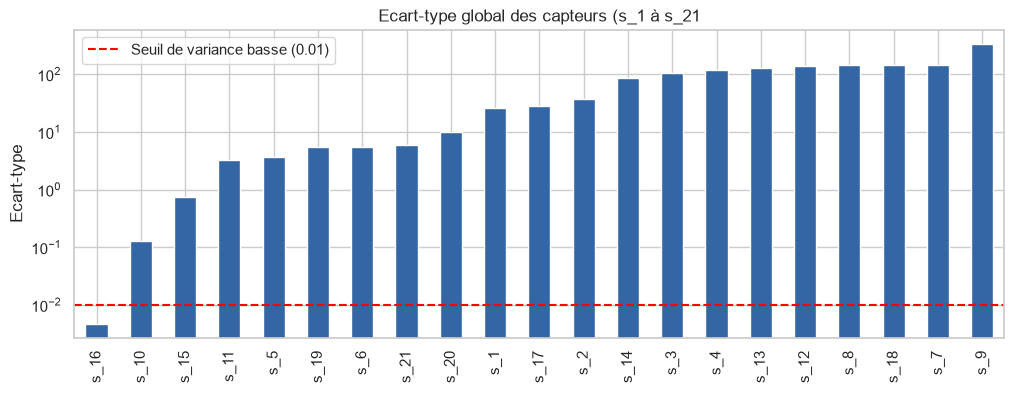

Capteurs à variance quasi-nulle à surveiller: ['s_16']


In [15]:
sensor_cols = [col for col in df_train.columns if col.startswith("s_")]

# Calcul de l'écart-type de chaque capteur sur l'ensemble du dataset
sensor_std = df_train[sensor_cols].std().sort_values()

plt.figure(figsize=(12,4))
sensor_std.plot(kind="bar", color="#3465a4")
plt.axhline(0.01, color="red", linestyle="--", label="Seuil de variance basse (0.01)")
plt.title("Ecart-type global des capteurs (s_1 à s_21")
plt.ylabel("Ecart-type")
plt.yscale("log")
plt.legend()
plt.show()

low_var = sensor_std[sensor_std < 0.01].index.tolist()
print(f"Capteurs à variance quasi-nulle à surveiller: {low_var}")


# 6. Déétection des conditions opératoires (régimes de vol)

FD004 ne fonctionne pas en laboratoire à régime fixe mais simule 6 conditions de vol distinctes déterminées par les trois réglages (variables de commande de vol):
  - setting_1:altitude (en pieds)
  - setting_2:vitesse en nombre de Mach
  - setting_3:angle d'ouverture de la tuyère (TRA — Throttle Resolver Angle)

In [16]:
settings = ["setting_1", "setting_2", "setting_3"]

# Regroupement des réglages pour compter les combinaisons d'opérations
regimes = df_train.groupby(settings).size().reset_index(name="count")# Rassemble toutes lignes qui partagent exactement le même triplet (setting_1, setting_2, setting_3) et compte combien de cycles d'enregistrement on eu lieu sous cette combinaison
# .reset transforme ce résultat en un tableau avec une colone count indiquant le nombre d'occurrences pour chaque combinaison
print(f"Nombre de combinaisons de réglages trouvées: {len(regimes)}")
display(regimes)

Nombre de combinaisons de réglages trouvées: 10232


,setting_1,setting_2,setting_3,count
0,0.000,0.0000,100.0,94
1,0.000,0.0001,100.0,3
2,0.000,0.0002,100.0,5
3,0.000,0.0003,100.0,1
4,0.000,0.0004,100.0,4
...,...,...,...,...
10227,42.008,0.8412,100.0,2
10228,42.008,0.8416,100.0,3
10229,42.008,0.8418,100.0,2
10230,42.008,0.8419,100.0,2
